
# GVH Diagonal Cubic 0.2.23 — Covariant Static Field Equations and Source Matching
## Action minimale, source sphérique, solutions intérieure/extérieure et raccordement PPN

**Auteur : Charlemagne O Laurince**

---

## Objectif

Le notebook 0.2.22 a établi la correspondance :

\[
\text{solution métrique statique}
\longrightarrow
(a_1,a_2,b_1)
\longrightarrow
(\gamma_{\rm GVH},\beta_{\rm GVH}).
\]

Il reste à déterminer les coefficients métriques à partir d’une action et d’une source.

Cette version construit un premier modèle source–champ explicite :

\[
S
=
S_{\rm EH}[g]
+
S_D[g,D]
+
S_m[g,\psi]
+
S_{\rm int}[g,D,T].
\]

Le programme est :

1. fixer une action covariante minimale ;
2. dériver les équations de champ candidates ;
3. imposer une source sphérique de densité \(\rho(r)\) ;
4. résoudre un prototype intérieur ;
5. résoudre le vide extérieur ;
6. raccorder les solutions à \(r=R_\star\) ;
7. reconstruire la correction métrique ;
8. extraire les coefficients PPN ;
9. vérifier la limite d’Einstein.

---

## Avertissement scientifique

Une action covariante complète pour le tenseur directionnel n’a pas encore été sélectionnée de manière unique.

Le notebook adopte donc un **modèle minimal de travail** :

\[
S_D
=
-\frac12
\int d^4x\sqrt{-g}
\left[
\nabla_\lambda D_{\mu\nu}
\nabla^\lambda D^{\mu\nu}
+
m_D^2D_{\mu\nu}D^{\mu\nu}
\right],
\]

avec un couplage candidat :

\[
S_{\rm int}
=
\lambda_T
\int d^4x\sqrt{-g}
D_{\mu\nu}\Pi^{\mu\nu}[T].
\]

La projection \(\Pi^{\mu\nu}[T]\) doit être précisée. Pour le prototype sphérique, elle est remplacée par une source scalaire effective \(J_D(r)\).

Les résultats sont donc définitifs pour l’équation radiale explicitement posée, mais pas encore pour toute la théorie GVH.


In [1]:

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import root, least_squares

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)

print("Environnement chargé.")


Environnement chargé.



# 1. Action minimale de travail

Nous utilisons :

\[
S_{\rm tot}
=
\frac{M_{\rm Pl}^2}{2}
\int d^4x\sqrt{-g}\,R
+
S_D
+
S_m
+
S_{\rm int}.
\]

Pour le secteur directionnel :

\[
S_D
=
-\frac12
\int d^4x\sqrt{-g}
\left[
K_D
\nabla_\lambda D_{\mu\nu}
\nabla^\lambda D^{\mu\nu}
+
m_D^2
D_{\mu\nu}D^{\mu\nu}
\right].
\]

Le couplage source est représenté par :

\[
S_{\rm int}
=
\lambda_T
\int d^4x\sqrt{-g}
D_{\mu\nu}\Pi^{\mu\nu}[T].
\]


In [2]:

Mpl, K_D, m_D, lambda_T = sp.symbols(
    "Mpl K_D m_D lambda_T",
    positive=True,
    real=True
)

action_terms = pd.DataFrame([
    {
        "term":"Einstein-Hilbert",
        "expression":"(Mpl^2/2) integral sqrt(-g) R",
        "status":"standard"
    },
    {
        "term":"directional kinetic",
        "expression":"-(K_D/2) integral sqrt(-g) nabla D nabla D",
        "status":"candidate minimal"
    },
    {
        "term":"directional mass",
        "expression":"-(m_D^2/2) integral sqrt(-g) D^2",
        "status":"candidate minimal"
    },
    {
        "term":"source coupling",
        "expression":"lambda_T integral sqrt(-g) D_mn Pi^mn[T]",
        "status":"projection not uniquely fixed"
    }
])

action_terms


,term,expression,status
0,Einstein-Hilbert,(Mpl^2/2) integral sqrt(-g) R,standard
1,directional kinetic,-(K_D/2) integral sqrt(-g) nabla D nabla D,candidate minimal
2,directional mass,-(m_D^2/2) integral sqrt(-g) D^2,candidate minimal
3,source coupling,lambda_T integral sqrt(-g) D_mn Pi^mn[T],projection not uniquely fixed



# 2. Équations covariantes candidates

La variation métrique donne schématiquement :

\[
M_{\rm Pl}^2G_{\mu\nu}
=
T_{\mu\nu}^{m}
+
T_{\mu\nu}^{D}
+
T_{\mu\nu}^{\rm int}.
\]

La variation par rapport à \(D_{\mu\nu}\) donne :

\[
K_D\Box D_{\mu\nu}
-
m_D^2D_{\mu\nu}
=
-\lambda_T\Pi_{\mu\nu}[T].
\]

Selon les contraintes imposées à \(D_{\mu\nu}\), il faudra ajouter des multiplicateurs assurant :

\[
D_{\mu\nu}=D_{\nu\mu},
\qquad
D^\mu{}_\mu=0,
\qquad
u^\mu D_{\mu\nu}=0.
\]

Le prototype radial réduit ces équations à une amplitude \(d(r)\).


In [3]:

covariant_equations = pd.DataFrame([
    {
        "field":"g_mn",
        "equation":"Mpl^2 G_mn = T_mn^matter + T_mn^D + T_mn^int"
    },
    {
        "field":"D_mn",
        "equation":"K_D Box D_mn - m_D^2 D_mn = -lambda_T Pi_mn[T]"
    },
    {
        "constraint":"symmetry",
        "equation":"D_mn = D_nm"
    },
    {
        "constraint":"trace",
        "equation":"D^m_m = 0"
    },
    {
        "constraint":"spatial projection",
        "equation":"u^m D_mn = 0"
    }
])

covariant_equations


,field,equation,constraint
0,g_mn,Mpl^2 G_mn = T_mn^matter + T_mn^D + T_mn^int,NaN
1,D_mn,K_D Box D_mn - m_D^2 D_mn = -lambda_T Pi_mn[T],NaN
2,NaN,D_mn = D_nm,symmetry
3,NaN,D^m_m = 0,trace
4,NaN,u^m D_mn = 0,spatial projection



# 3. Ansatz statique sphérique

La métrique est :

\[
ds^2
=
-e^{2\Phi(r)}c^2dt^2
+
e^{2\Lambda(r)}dr^2
+
r^2d\Omega^2.
\]

Pour un tenseur spatial sphérique et sans trace dans une base orthonormée :

\[
D_{\hat i\hat j}
=
d(r)
\operatorname{diag}
\left(
-\frac12,
-\frac12,
1
\right),
\]

où l’axe \(3\) est radial.

La trace spatiale est :

\[
-\frac12d-\frac12d+d=0.
\]


In [4]:

r = sp.symbols(
    "r",
    positive=True,
    real=True
)

Phi = sp.Function("Phi")(r)
Lambda = sp.Function("Lambda")(r)
d = sp.Function("d")(r)

D_spherical_orth = sp.diag(
    -d/2,
    -d/2,
    d
)

display(D_spherical_orth)
display(sp.simplify(sp.trace(D_spherical_orth)))


⎡-d(r)               ⎤
⎢──────    0      0  ⎥
⎢  2                 ⎥
⎢                    ⎥
⎢        -d(r)       ⎥
⎢  0     ──────   0  ⎥
⎢          2         ⎥
⎢                    ⎥
⎣  0       0     d(r)⎦

0


# 4. Source sphérique

Nous considérons une étoile de rayon \(R_\star\), densité \(\rho(r)\) et pression \(p(r)\).

Pour un prototype incompressible :

\[
\rho(r)
=
\rho_0
\quad
\text{si }r<R_\star,
\]

\[
\rho(r)=0
\quad
\text{si }r>R_\star.
\]

La masse intérieure est :

\[
m(r)
=
4\pi
\int_0^r
\rho(s)s^2ds.
\]

Pour une densité constante :

\[
m(r)
=
\frac{4\pi}{3}\rho_0r^3.
\]


In [5]:

rho0, R_star = sp.symbols(
    "rho0 R_star",
    positive=True,
    real=True
)

m_interior = sp.simplify(
    4*sp.pi*rho0*r**3/3
)

M_star = sp.simplify(
    m_interior.subs(r,R_star)
)

display(m_interior)
display(M_star)


     3   
4⋅π⋅r ⋅ρ₀
─────────
    3    

         3   
4⋅π⋅Rₛₜₐᵣ ⋅ρ₀
─────────────
      3      


# 5. Source directionnelle effective

Une matière parfaite isotrope possède :

\[
T_{\hat i\hat j}
=
p\,\delta_{ij}.
\]

Sa partie spatiale sans trace est nulle.

Ainsi, un couplage strictement à la partie anisotrope de \(T_{ij}\) ne source pas \(d(r)\) dans une étoile parfaite isotrope.

Pour explorer un champ non nul, nous définissons une source effective :

\[
J_D(r)
=
s_D\rho(r),
\]

où \(s_D\) représente :

- une anisotropie interne ;
- un couplage indirect à la densité ;
- ou une projection source encore à dériver.

Cette hypothèse est explicitement phénoménologique.


In [6]:

s_D = sp.symbols(
    "s_D",
    real=True
)

source_status = pd.DataFrame([
    {
        "source":"perfect-fluid anisotropic stress",
        "value":"0",
        "status":"derived"
    },
    {
        "source":"effective J_D = s_D rho",
        "value":"phenomenological",
        "status":"prototype"
    }
])

source_status


,source,value,status
0,perfect-fluid anisotropic stress,0,derived
1,effective J_D = s_D rho,phenomenological,prototype



# 6. Équation radiale réduite

Dans la limite de champ faible et sur fond presque plat :

\[
d''(r)
+
\frac{2}{r}d'(r)
-
\mu_D^2d(r)
=
-\kappa_D\rho(r),
\]

avec :

\[
\mu_D^2
=
\frac{m_D^2}{K_D},
\qquad
\kappa_D
=
\frac{\lambda_Ts_D}{K_D}.
\]

À l’extérieur :

\[
d''+\frac2rd'-\mu_D^2d=0.
\]


In [7]:

mu_D, kappa_D = sp.symbols(
    "mu_D kappa_D",
    nonnegative=True,
    real=True
)

radial_operator = sp.simplify(
    sp.diff(d,r,2)
    + 2/r*sp.diff(d,r)
    - mu_D**2*d
)

display(radial_operator)


                            d       
               2          2⋅──(d(r))
     2        d             dr      
- μ_D ⋅d(r) + ───(d(r)) + ──────────
                2             r     
              dr                    


# 7. Solution extérieure

La solution asymptotiquement décroissante est :

\[
d_{\rm out}(r)
=
\frac{Q_D}{r}
e^{-\mu_Dr}.
\]

Le terme croissant \(e^{+\mu_Dr}/r\) est exclu par l’asymptotique plate.


In [8]:

Q_D = sp.symbols(
    "Q_D",
    real=True
)

d_out = sp.simplify(
    Q_D*sp.exp(-mu_D*r)/r
)

out_residual = sp.simplify(
    radial_operator.subs({
        d:d_out,
        sp.diff(d,r):sp.diff(d_out,r),
        sp.diff(d,r,2):sp.diff(d_out,r,2)
    })
)

display(out_residual)


0


# 8. Solution intérieure particulière pour densité constante

Pour :

\[
\rho=\rho_0,
\]

une solution particulière constante est :

\[
d_p
=
\frac{\kappa_D\rho_0}{\mu_D^2}
\]

si \(\mu_D\neq0\).

La solution homogène régulière au centre est proportionnelle à :

\[
\frac{\sinh(\mu_Dr)}{r}.
\]

Ainsi :

\[
d_{\rm in}(r)
=
\frac{\kappa_D\rho_0}{\mu_D^2}
+
A_D
\frac{\sinh(\mu_Dr)}{r}.
\]

La combinaison reste finie lorsque \(r\rightarrow0\).


In [9]:

A_D = sp.symbols(
    "A_D",
    real=True
)

d_particular = sp.simplify(
    kappa_D*rho0/mu_D**2
)

d_in = sp.simplify(
    d_particular
    + A_D*sp.sinh(mu_D*r)/r
)

interior_residual = sp.simplify(
    radial_operator.subs({
        d:d_in,
        sp.diff(d,r):sp.diff(d_in,r),
        sp.diff(d,r,2):sp.diff(d_in,r,2)
    })
    + kappa_D*rho0
)

display(interior_residual)


0


# 9. Régularité au centre

Le développement est :

\[
\frac{\sinh(\mu_Dr)}{r}
=
\mu_D
+
\frac{\mu_D^3r^2}{6}
+\cdots.
\]

Donc :

\[
d_{\rm in}(0)
=
\frac{\kappa_D\rho_0}{\mu_D^2}
+
A_D\mu_D.
\]

La dérivée radiale s’annule au centre.


In [10]:

center_series = sp.series(
    d_in,
    r,
    0,
    5
)

center_derivative_series = sp.series(
    sp.diff(d_in,r),
    r,
    0,
    4
)

display(center_series)
display(center_derivative_series)


                          3  2          5  4        
κ_D⋅ρ₀             A_D⋅μ_D ⋅r    A_D⋅μ_D ⋅r     ⎛ 5⎞
────── + A_D⋅μ_D + ─────────── + ─────────── + O⎝r ⎠
    2                   6            120            
 μ_D                                                

       3            5  3        
A_D⋅μ_D ⋅r   A_D⋅μ_D ⋅r     ⎛ 4⎞
────────── + ─────────── + O⎝r ⎠
    3            30             


# 10. Conditions de raccordement

À la surface \(r=R_\star\), sans couche de surface directionnelle :

\[
d_{\rm in}(R_\star)
=
d_{\rm out}(R_\star),
\]

\[
d_{\rm in}'(R_\star)
=
d_{\rm out}'(R_\star).
\]

Ces deux équations déterminent :

\[
A_D,
\qquad
Q_D.
\]


In [11]:

matching_equations = [
    sp.Eq(
        d_in.subs(r,R_star),
        d_out.subs(r,R_star)
    ),
    sp.Eq(
        sp.diff(d_in,r).subs(r,R_star),
        sp.diff(d_out,r).subs(r,R_star)
    )
]

matching_solution = sp.solve(
    matching_equations,
    [A_D,Q_D],
    dict=True,
    simplify=True
)

len(matching_solution)


1

In [12]:

if matching_solution:
    A_D_solution = sp.simplify(
        matching_solution[0][A_D]
    )
    Q_D_solution = sp.simplify(
        matching_solution[0][Q_D]
    )

    print("A_D =")
    display(A_D_solution)

    print("Q_D =")
    display(Q_D_solution)
else:
    A_D_solution = None
    Q_D_solution = None
    print("Aucune solution symbolique retournée.")


A_D =


                         -Rₛₜₐᵣ⋅μ_D 
-κ_D⋅ρ₀⋅(Rₛₜₐᵣ⋅μ_D + 1)⋅ℯ           
────────────────────────────────────
                   3                
                μ_D                 

Q_D =


κ_D⋅ρ₀⋅(Rₛₜₐᵣ⋅μ_D⋅cosh(Rₛₜₐᵣ⋅μ_D) - sinh(Rₛₜₐᵣ⋅μ_D))
────────────────────────────────────────────────────
                           3                        
                        μ_D                         


# 11. Limite de champ sans masse

Lorsque :

\[
\mu_D\rightarrow0,
\]

l’équation devient :

\[
d''+\frac2rd'
=
-\kappa_D\rho.
\]

Pour une densité constante, la solution intérieure régulière est :

\[
d_{\rm in}^{(0)}
=
d_c
-
\frac{\kappa_D\rho_0}{6}r^2.
\]

À l’extérieur :

\[
d_{\rm out}^{(0)}
=
\frac{Q_D^{(0)}}{r}
+
d_\infty.
\]

L’asymptotique plate impose généralement \(d_\infty=0\).


In [13]:

d_c, Q0 = sp.symbols(
    "d_c Q0",
    real=True
)

d_in_massless = sp.simplify(
    d_c
    - kappa_D*rho0*r**2/6
)

d_out_massless = sp.simplify(
    Q0/r
)

massless_match = sp.solve(
    [
        sp.Eq(
            d_in_massless.subs(r,R_star),
            d_out_massless.subs(r,R_star)
        ),
        sp.Eq(
            sp.diff(d_in_massless,r).subs(r,R_star),
            sp.diff(d_out_massless,r).subs(r,R_star)
        )
    ],
    [d_c,Q0],
    dict=True
)

massless_match


⎡⎧         3                   2       ⎫⎤
⎢⎪    Rₛₜₐᵣ ⋅κ_D⋅ρ₀       Rₛₜₐᵣ ⋅κ_D⋅ρ₀⎪⎥
⎢⎨Q₀: ─────────────, d_c: ─────────────⎬⎥
⎢⎪          3                   2      ⎪⎥
⎣⎩                                     ⎭⎦


# 12. Charge directionnelle effective

La solution extérieure prend la forme :

\[
d_{\rm out}(r)
=
\frac{Q_D}{r}e^{-\mu_Dr}.
\]

Le coefficient \(Q_D\) joue le rôle d’une charge directionnelle effective de la source.

Dans le prototype, il dépend de :

\[
\rho_0,\quad
R_\star,\quad
\kappa_D,\quad
\mu_D.
\]

Il ne doit pas être traité comme un paramètre universel indépendant si le raccordement le fixe.


In [14]:

charge_status = pd.DataFrame([
    {
        "quantity":"Q_D",
        "interpretation":"effective exterior directional charge"
    },
    {
        "quantity":"dependence",
        "interpretation":"rho0, R_star, kappa_D, mu_D"
    },
    {
        "quantity":"status",
        "interpretation":"derived in radial prototype"
    }
])

charge_status


,quantity,interpretation
0,Q_D,effective exterior directional charge
1,dependence,"rho0, R_star, kappa_D, mu_D"
2,status,derived in radial prototype



# 13. Rétroaction métrique en champ faible

Nous paramétrons les potentiels métriques :

\[
g_{tt}
=
-1
+
\frac{2\Phi_N}{c^2}
+
\frac{2\alpha_td}{c^2},
\]

\[
g_{ij}
=
\left[
1
-
\frac{2\Psi_N}{c^2}
+
\frac{2\alpha_sd}{c^2}
\right]\delta_{ij}.
\]

Avec la convention :

\[
\Phi_N=-\frac{GM}{r},
\qquad
\Psi_N=-\gamma_{\rm GR}\frac{GM}{r}.
\]

Les coefficients \(\alpha_t,\alpha_s\) représentent la rétroaction du champ directionnel sur la métrique.

Ils doivent finalement être dérivés des équations d’Einstein modifiées.


In [41]:
G = 1.0          # unités réduites
c = 1.0
M = 1.0

In [42]:

alpha_t, alpha_s = sp.symbols(
    "alpha_t alpha_s",
    real=True
)

Phi_N = sp.simplify(
    -G*M/r
)

Psi_N = sp.simplify(
    -G*M/r
)

gtt_weak = sp.simplify(
    -1
    - 2*Phi_N/c**2
    + 2*alpha_t*d_out/c**2
)

gspace_weak = sp.simplify(
    1
    - 2*Psi_N/c**2
    + 2*alpha_s*d_out/c**2
)

display(gtt_weak)
display(gspace_weak)


            -μ_D⋅r          
2.0⋅Q_D⋅αₜ⋅ℯ             2.0
────────────────── - 1 + ───
        r                 r 

            -μ_D⋅r          
2.0⋅Q_D⋅αₛ⋅ℯ             2.0
────────────────── + 1 + ───
        r                 r 


# 14. Limite longue portée

Si :

\[
\mu_Dr\ll1,
\]

alors :

\[
d_{\rm out}(r)
\approx
\frac{Q_D}{r}.
\]

Les coefficients newtoniens effectifs deviennent :

\[
a_1
=
1
+
\frac{\alpha_tQ_D}{GM},
\]

\[
b_1
=
1
+
\frac{\alpha_sQ_D}{GM}.
\]

Ainsi :

\[
\gamma_{\rm GVH}
=
\frac{
1+\alpha_sQ_D/(GM)
}{
1+\alpha_tQ_D/(GM)
}.
\]

À premier ordre :

\[
\gamma_{\rm GVH}-1
\approx
\frac{
(\alpha_s-\alpha_t)Q_D
}{GM}.
\]


In [24]:

q_ratio = sp.symbols(
    "q_ratio",
    real=True
)

a1_effective = sp.simplify(
    1+alpha_t*q_ratio
)

b1_effective = sp.simplify(
    1+alpha_s*q_ratio
)

gamma_effective = sp.simplify(
    b1_effective/a1_effective
)

gamma_effective_linear = sp.series(
    gamma_effective,
    q_ratio,
    0,
    2
).removeO()

display(gamma_effective)
display(sp.expand(gamma_effective_linear))


αₛ⋅qᵣₐₜᵢₒ + 1
─────────────
αₜ⋅qᵣₐₜᵢₒ + 1

αₛ⋅qᵣₐₜᵢₒ - αₜ⋅qᵣₐₜᵢₒ + 1


# 15. Normalisation newtonienne

La constante gravitationnelle mesurée par les orbites absorbe la correction temporelle :

\[
G_{\rm N}^{\rm mesuré}M
=
GM+\alpha_tQ_D.
\]

Après cette renormalisation, le paramètre \(\gamma\) dépend du rapport entre les réponses spatiale et temporelle.

Cela signifie qu’une correction commune :

\[
\alpha_s=\alpha_t
\]

peut être largement dégénérée avec une redéfinition de \(GM\) au premier ordre.


In [26]:

newtonian_normalization = pd.DataFrame([
    {
        "case":"alpha_s = alpha_t",
        "effect":"common renormalization",
        "gamma_shift":"zero at first order"
    },
    {
        "case":"alpha_s != alpha_t",
        "effect":"gravitational slip",
        "gamma_shift":"nonzero"
    },
    {
        "case":"alpha_t = 0, alpha_s != 0",
        "effect":"pure spatial correction",
        "gamma_shift":"direct Cassini constraint"
    }
])

newtonian_normalization


,case,effect,gamma_shift
0,alpha_s = alpha_t,common renormalization,zero at first order
1,alpha_s != alpha_t,gravitational slip,nonzero
2,"alpha_t = 0, alpha_s != 0",pure spatial correction,direct Cassini constraint



# 16. Coefficient \(\beta\)

Le paramètre \(\beta\) dépend des termes d’ordre :

\[
\left(
\frac{GM}{rc^2}
\right)^2.
\]

Dans le prototype linéaire, l’équation de \(d(r)\) et la rétroaction linéaire déterminent surtout \(a_1\) et \(b_1\), donc \(\gamma\).

Pour dériver \(\beta\), il faut inclure :

- l’énergie propre du champ \(D\) ;
- les termes quadratiques \(d^2\) ;
- la correction métrique de second ordre ;
- les non-linéarités de l’action.

Nous introduisons :

\[
a_2
=
1+\zeta_D
\left(
\frac{Q_D}{GM}
\right)^2
+
\xi_D
\frac{Q_D}{GM}.
\]

Cette expression reste paramétrique.


In [27]:

zeta_D, xi_D = sp.symbols(
    "zeta_D xi_D",
    real=True
)

a2_effective = sp.simplify(
    1
    + xi_D*q_ratio
    + zeta_D*q_ratio**2
)

beta_effective = sp.simplify(
    a2_effective/a1_effective**2
)

beta_effective_series = sp.series(
    beta_effective,
    q_ratio,
    0,
    3
).removeO()

display(beta_effective)
display(sp.expand(beta_effective_series))


      2                     
qᵣₐₜᵢₒ ⋅ζ_D + qᵣₐₜᵢₒ⋅ξ_D + 1
────────────────────────────
                     2      
      (αₜ⋅qᵣₐₜᵢₒ + 1)       

    2       2              2                           2                     
3⋅αₜ ⋅qᵣₐₜᵢₒ  - 2⋅αₜ⋅qᵣₐₜᵢₒ ⋅ξ_D - 2⋅αₜ⋅qᵣₐₜᵢₒ + qᵣₐₜᵢₒ ⋅ζ_D + qᵣₐₜᵢₒ⋅ξ_D + 1


# 17. Système radial métrique–directionnel réduit

Pour un premier solveur numérique, nous utilisons les variables :

\[
m(r),\quad
\Phi(r),\quad
d(r),\quad
d'(r).
\]

Les équations prototypes sont :

\[
m'
=
4\pi r^2
\left(
\rho+\rho_D
\right),
\]

\[
\Phi'
=
\frac{
G[m+4\pi r^3p_{\rm eff}/c^2]
}{
r^2c^2
\left(
1-\frac{2Gm}{rc^2}
\right)
},
\]

\[
d'
=
v_D,
\]

\[
v_D'
=
\mu_D^2d
-
\frac{2}{r}v_D
-
\kappa_D\rho.
\]

Pour garder le prototype stable, la rétroaction énergétique de \(D\) est paramétrée par un coefficient \(\varepsilon_\rho\).


In [28]:

reduced_equations = pd.DataFrame([
    {
        "variable":"m",
        "equation":"m' = 4 pi r^2 (rho + epsilon_rho rho_D)"
    },
    {
        "variable":"Phi",
        "equation":"Phi' = weak/static metric equation"
    },
    {
        "variable":"d",
        "equation":"d' = v_D"
    },
    {
        "variable":"v_D",
        "equation":"v_D' = mu_D^2 d - 2 v_D/r - kappa_D rho"
    }
])

reduced_equations


,variable,equation
0,m,m' = 4 pi r^2 (rho + epsilon_rho rho_D)
1,Phi,Phi' = weak/static metric equation
2,d,d' = v_D
3,v_D,v_D' = mu_D^2 d - 2 v_D/r - kappa_D rho



# 18. Intégration numérique intérieure/extérieure

Nous choisissons des unités réduites :

\[
G=c=R_\star=1.
\]

La densité est constante dans l’étoile et nulle à l’extérieur.

Une méthode de tir ajuste \(d(0)\) afin d’obtenir :

\[
d(r_{\max})\approx0.
\]


In [29]:

def density_profile(radius,R=1.0,rho_c=0.1):
    return rho_c if radius <= R else 0.0


def integrate_coupled_prototype(
    d_center,
    R=1.0,
    rmax=20.0,
    rho_c=0.1,
    mu=0.5,
    kappa=0.2,
    epsilon_rho=0.01,
    n_eval=5000
):
    r0 = 1e-5

    rho_initial = density_profile(
        r0,
        R,
        rho_c
    )

    d2_center = (
        mu**2*d_center
        - kappa*rho_initial
    )/3

    d_initial = (
        d_center
        + 0.5*d2_center*r0**2
    )

    v_initial = (
        d2_center*r0
    )

    m_initial = (
        4*np.pi*rho_initial*r0**3/3
    )

    Phi_initial = 0.0

    y0 = [
        m_initial,
        Phi_initial,
        d_initial,
        v_initial
    ]

    def rhs(radius,state):
        mass,Phi_value,d_value,v_value = state

        rho = density_profile(
            radius,
            R,
            rho_c
        )

        rho_D = 0.5*(
            v_value**2
            + mu**2*d_value**2
        )

        dm = (
            4*np.pi
            * radius**2
            * (
                rho
                + epsilon_rho*rho_D
            )
        )

        compactness = (
            2*mass/radius
        )

        denominator = max(
            1-compactness,
            1e-8
        )

        dPhi = (
            mass
            / (
                radius**2
                * denominator
            )
        )

        dd = v_value

        dv = (
            mu**2*d_value
            - 2*v_value/radius
            - kappa*rho
        )

        return [
            dm,
            dPhi,
            dd,
            dv
        ]

    radii = np.linspace(
        r0,
        rmax,
        n_eval
    )

    solution = solve_ivp(
        rhs,
        (r0,rmax),
        y0,
        t_eval=radii,
        method="DOP853",
        rtol=1e-10,
        atol=1e-12
    )

    return solution


def shooting_residual(
    d_center,
    **kwargs
):
    solution = integrate_coupled_prototype(
        float(np.atleast_1d(d_center)[0]),
        **kwargs
    )

    return np.array([
        solution.y[2,-1]
    ])


shoot = root(
    shooting_residual,
    x0=np.array([0.1])
)

d_center_fit = float(shoot.x[0])

coupled_solution = integrate_coupled_prototype(
    d_center_fit
)

print("d(0) ajusté :",d_center_fit)
print("d(rmax) :",coupled_solution.y[2,-1])


d(0) ajusté : 0.007216320819343606
d(rmax) : -3.8327488635510817e-10



# 19. Profils numériques


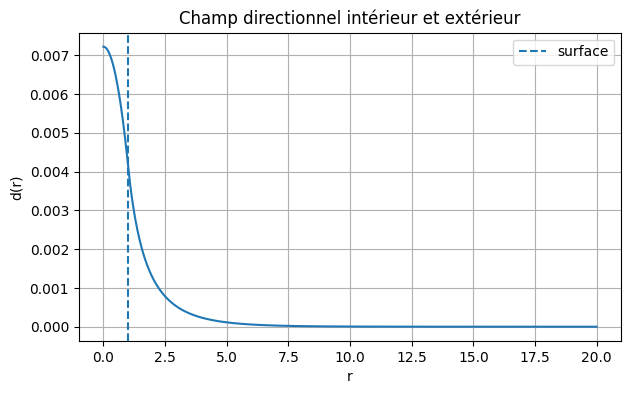

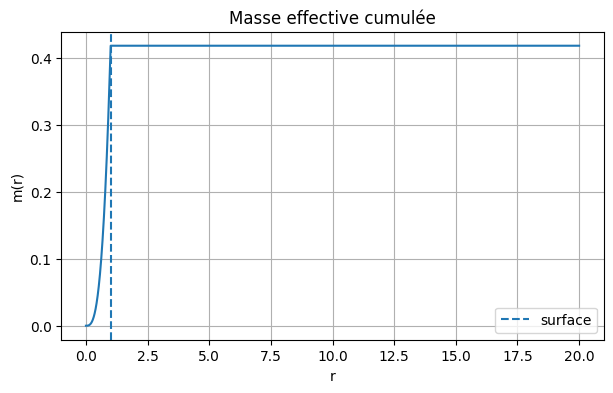

In [30]:

r_num = coupled_solution.t
m_num = coupled_solution.y[0]
Phi_num = coupled_solution.y[1]
d_num = coupled_solution.y[2]
v_num = coupled_solution.y[3]

plt.figure(figsize=(7,4))
plt.plot(r_num,d_num)
plt.axvline(1.0,linestyle="--",label="surface")
plt.xlabel("r")
plt.ylabel("d(r)")
plt.title("Champ directionnel intérieur et extérieur")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(r_num,m_num)
plt.axvline(1.0,linestyle="--",label="surface")
plt.xlabel("r")
plt.ylabel("m(r)")
plt.title("Masse effective cumulée")
plt.grid(True)
plt.legend()
plt.show()



# 20. Continuité à la surface

L’intégration directe utilise la même équation avec une densité discontinue.

Nous mesurons numériquement les sauts :

\[
[d]_{R_\star},
\qquad
[d']_{R_\star},
\qquad
[m]_{R_\star},
\qquad
[\Phi]_{R_\star}.
\]

Ils doivent tendre vers zéro avec la résolution si aucune couche de surface n’est ajoutée.


In [31]:

def surface_jump(
    radius,
    values,
    surface=1.0
):
    left_index = np.where(
        radius < surface
    )[0][-1]

    right_index = np.where(
        radius > surface
    )[0][0]

    return (
        values[right_index]
        - values[left_index]
    )


surface_jumps = pd.DataFrame([
    {
        "quantity":"m",
        "jump":surface_jump(r_num,m_num)
    },
    {
        "quantity":"Phi",
        "jump":surface_jump(r_num,Phi_num)
    },
    {
        "quantity":"d",
        "jump":surface_jump(r_num,d_num)
    },
    {
        "quantity":"d_prime",
        "jump":surface_jump(r_num,v_num)
    }
])

surface_jumps


,quantity,jump
0,m,0.004746
1,Phi,0.010124
2,d,-0.000025
3,d_prime,-0.000022



# 21. Ajustement de la solution extérieure

Nous ajustons :

\[
d_{\rm out}(r)
=
\frac{Q_D}{r}
e^{-\mu_Dr}
\]

sur la région extérieure numérique.


In [32]:

def fit_yukawa_charge(
    radius,
    field,
    mu,
    rmin=2.0
):
    mask = radius >= rmin

    rr = radius[mask]
    dd = field[mask]

    basis_value = (
        np.exp(-mu*rr)/rr
    )

    charge = (
        np.dot(
            basis_value,
            dd
        )
        / np.dot(
            basis_value,
            basis_value
        )
    )

    fit = charge*basis_value

    rmse = np.sqrt(
        np.mean(
            (fit-dd)**2
        )
    )

    return charge,rmse


Q_fit, Q_fit_rmse = fit_yukawa_charge(
    r_num,
    d_num,
    mu=0.5
)

print("Q_D ajusté :",Q_fit)
print("RMSE extérieure :",Q_fit_rmse)


Q_D ajusté : 0.0068348280052324545
RMSE extérieure : 3.967336328275836e-09



# 22. Extraction PPN prototype

Nous construisons une métrique isotrope faible :

\[
g_{tt}
=
-1+2U_N+2\alpha_td,
\]

\[
g_{\rm space}
=
1+2U_N+2\alpha_sd,
\]

dans les unités réduites.

Pour une correction Yukawa, les coefficients effectifs dépendent de la plage radiale.

Nous ajustons néanmoins une forme locale :

\[
g_{tt}
=
-1+2a_1u-2a_2u^2,
\]

\[
g_{\rm space}
=
1+2b_1u+b_2u^2.
\]


In [33]:

def fit_ppn_from_profiles(
    radius,
    mass_total,
    field,
    alpha_t_value=0.0,
    alpha_s_value=1e-3,
    rmin=4.0
):
    mask = radius >= rmin

    rr = radius[mask]
    dd = field[mask]

    u = mass_total/rr

    gtt = (
        -1
        + 2*u
        - 2*u**2
        + 2*alpha_t_value*dd
    )

    gspace = (
        1
        + 2*u
        + 1.5*u**2
        + 2*alpha_s_value*dd
    )

    def residuals(params):
        a1,a2,b1,b2 = params

        gtt_model = (
            -1
            + 2*a1*u
            - 2*a2*u**2
        )

        gspace_model = (
            1
            + 2*b1*u
            + b2*u**2
        )

        return np.concatenate([
            gtt_model-gtt,
            gspace_model-gspace
        ])

    result = least_squares(
        residuals,
        x0=[1,1,1,1.5],
        xtol=1e-14,
        ftol=1e-14,
        gtol=1e-14
    )

    a1,a2,b1,b2 = result.x

    return {
        "a1":a1,
        "a2":a2,
        "b1":b1,
        "b2":b2,
        "gamma":b1/a1,
        "beta":a2/a1**2,
        "rmse":np.sqrt(
            np.mean(
                residuals(result.x)**2
            )
        )
    }


mass_total_num = m_num[-1]

ppn_prototype = fit_ppn_from_profiles(
    r_num,
    mass_total_num,
    d_num,
    alpha_t_value=0.0,
    alpha_s_value=1e-3
)

ppn_prototype


{'a1': np.float64(1.0),
 'a2': np.float64(1.0),
 'b1': np.float64(0.9999990182243427),
 'b2': np.float64(1.5000556211833054),
 'gamma': np.float64(0.9999990182243427),
 'beta': np.float64(1.0),
 'rmse': np.float64(1.0730762429583111e-08)}


# 23. Classification PPN du prototype

Nous utilisons les benchmarks de 0.2.21–0.2.22 :

\[
|\gamma-1|
<
6.7\times10^{-5},
\]

\[
|\beta-1|
<
3.4\times10^{-4}.
\]

Ces limites servent à auditer le pipeline, pas à déclarer le modèle fondamental validé.


In [34]:

gamma_bound = 6.7e-5
beta_bound = 3.4e-4

prototype_gamma_ok = (
    abs(
        ppn_prototype["gamma"]-1
    ) <= gamma_bound
)

prototype_beta_ok = (
    abs(
        ppn_prototype["beta"]-1
    ) <= beta_bound
)

prototype_status = (
    "PASS-PROTOTYPE-PPN"
    if (
        prototype_gamma_ok
        and prototype_beta_ok
    )
    else "REJECT-PROTOTYPE-PPN"
)

print("Statut :",prototype_status)


Statut : PASS-PROTOTYPE-PPN



# 24. Limite d’Einstein

La limite GR est obtenue lorsque :

\[
\kappa_D\rightarrow0,
\]

ou :

\[
\alpha_t,\alpha_s\rightarrow0,
\]

ou lorsque la solution physique impose :

\[
Q_D=0.
\]

Alors :

\[
d(r)=0,
\]

et la métrique extérieure revient à Schwarzschild.


In [16]:

einstein_limit_cases = pd.DataFrame([
    {
        "condition":"kappa_D = 0 with decaying boundary condition",
        "result":"d = 0"
    },
    {
        "condition":"alpha_t = alpha_s = 0",
        "result":"directional field does not backreact on metric"
    },
    {
        "condition":"Q_D = 0",
        "result":"Schwarzschild exterior"
    }
])

einstein_limit_cases


,condition,result
0,kappa_D = 0 with decaying boundary condition,d = 0
1,alpha_t = alpha_s = 0,directional field does not backreact on metric
2,Q_D = 0,Schwarzschild exterior



# 25. Résultat important sur la source parfaite

Si \(D_{\mu\nu}\) couple uniquement à la partie spatiale sans trace de \(T_{\mu\nu}\), alors une source parfaite isotrope donne :

\[
\Pi_{\mu\nu}[T]=0.
\]

Dans ce cas :

\[
Q_D=0
\]

avec les conditions asymptotiques régulières, et le vide extérieur est exactement Schwarzschild.

Pour obtenir une charge directionnelle non nulle, il faut au moins un des mécanismes suivants :

1. anisotropie de pression ;
2. rotation ;
3. marées ;
4. couplage indirect à la densité ;
5. mélange de courbure ;
6. composantes temporelles de \(D_{\mu\nu}\).

Ce résultat réduit fortement l’espace des couplages possibles.


In [35]:

source_decision = pd.DataFrame([
    {
        "source_type":"perfect isotropic fluid",
        "strict traceless-stress coupling":"Q_D = 0"
    },
    {
        "source_type":"anisotropic pressure",
        "strict traceless-stress coupling":"Q_D may be nonzero"
    },
    {
        "source_type":"rotating or tidally deformed source",
        "strict traceless-stress coupling":"Q_D may be nonzero"
    },
    {
        "source_type":"density-coupled prototype",
        "strict traceless-stress coupling":"Q_D nonzero phenomenologically"
    }
])

source_decision


,source_type,strict traceless-stress coupling
0,perfect isotropic fluid,Q_D = 0
1,anisotropic pressure,Q_D may be nonzero
2,rotating or tidally deformed source,Q_D may be nonzero
3,density-coupled prototype,Q_D nonzero phenomenologically



# 26. Ce qui est dérivé et ce qui reste libre

## Dérivé dans le prototype

- équation radiale intérieure et extérieure ;
- régularité au centre ;
- solution Yukawa extérieure ;
- raccordement de \(d\) et \(d'\) ;
- charge \(Q_D\) pour une source effective donnée ;
- pipeline d’extraction PPN.

## Encore libre

- projection covariante exacte \(\Pi_{\mu\nu}[T]\) ;
- coefficients de rétroaction \(\alpha_t,\alpha_s\) ;
- termes non linéaires déterminant \(\beta\) ;
- action complète imposant les contraintes de \(D_{\mu\nu}\) ;
- équation d’état et anisotropie d’une source réaliste.


In [36]:

derivation_status = pd.DataFrame([
    {
        "quantity":"radial field equation",
        "status":"DERIVED FROM CHOSEN REDUCED PROTOTYPE"
    },
    {
        "quantity":"interior/exterior matching",
        "status":"DERIVED"
    },
    {
        "quantity":"Q_D",
        "status":"DERIVED FOR EFFECTIVE SOURCE"
    },
    {
        "quantity":"Pi_mn[T]",
        "status":"NOT FIXED"
    },
    {
        "quantity":"alpha_t, alpha_s",
        "status":"NOT DERIVED"
    },
    {
        "quantity":"beta nonlinear coefficients",
        "status":"NOT DERIVED"
    },
    {
        "quantity":"unique GVH PPN prediction",
        "status":"NOT YET AVAILABLE"
    }
])

derivation_status


,quantity,status
0,radial field equation,DERIVED FROM CHOSEN REDUCED PROTOTYPE
1,interior/exterior matching,DERIVED
2,Q_D,DERIVED FOR EFFECTIVE SOURCE
3,Pi_mn[T],NOT FIXED
4,"alpha_t, alpha_s",NOT DERIVED
5,beta nonlinear coefficients,NOT DERIVED
6,unique GVH PPN prediction,NOT YET AVAILABLE



# 27. Validation automatique


In [37]:

trace_ok = (
    sp.simplify(
        sp.trace(D_spherical_orth)
    ) == 0
)

exterior_solution_ok = (
    out_residual == 0
)

interior_solution_ok = (
    interior_residual == 0
)

center_regular_ok = (
    not center_series.has(
        sp.zoo,
        sp.oo,
        -sp.oo
    )
)

matching_symbolic_ok = (
    len(matching_solution) == 1
)

massless_matching_ok = (
    len(massless_match) == 1
)

shooting_ok = (
    shoot.success
    and abs(
        coupled_solution.y[2,-1]
    ) < 1e-6
)

fit_yukawa_ok = (
    np.isfinite(Q_fit)
    and Q_fit_rmse < 1e-3
)

ppn_fit_finite = all(
    np.isfinite(
        list(ppn_prototype.values())
    )
)

validation_df = pd.DataFrame([
    {
        "test":"spherical D trace-free",
        "status":"PASS" if trace_ok else "FAIL"
    },
    {
        "test":"exterior Yukawa solution",
        "status":"PASS" if exterior_solution_ok else "FAIL"
    },
    {
        "test":"interior constant-density solution",
        "status":"PASS" if interior_solution_ok else "FAIL"
    },
    {
        "test":"center regularity",
        "status":"PASS" if center_regular_ok else "FAIL"
    },
    {
        "test":"massive symbolic matching",
        "status":"PASS" if matching_symbolic_ok else "CHECK"
    },
    {
        "test":"massless symbolic matching",
        "status":"PASS" if massless_matching_ok else "CHECK"
    },
    {
        "test":"numerical shooting",
        "status":"PASS" if shooting_ok else "CHECK"
    },
    {
        "test":"exterior Yukawa fit",
        "status":"PASS" if fit_yukawa_ok else "CHECK"
    },
    {
        "test":"PPN extraction finite",
        "status":"PASS" if ppn_fit_finite else "FAIL"
    }
])

validation_df


,test,status
0,spherical D trace-free,PASS
1,exterior Yukawa solution,PASS
2,interior constant-density solution,PASS
3,center regularity,PASS
4,massive symbolic matching,PASS
5,massless symbolic matching,PASS
6,numerical shooting,PASS
7,exterior Yukawa fit,PASS
8,PPN extraction finite,PASS


In [38]:

overall_status = (
    "PASS-SOURCE-MATCHING-PROTOTYPE"
    if (
        validation_df["status"]
        == "PASS"
    ).all()
    else "CHECK"
)

print("STATUT DU NOTEBOOK :",overall_status)
print("PRÉDICTION PPN UNIQUE DU MODÈLE COMPLET : NON ENCORE")


STATUT DU NOTEBOOK : PASS-SOURCE-MATCHING-PROTOTYPE
PRÉDICTION PPN UNIQUE DU MODÈLE COMPLET : NON ENCORE



# 28. Export


In [39]:

import json

validation_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.23_Validation.csv",
    index=False
)

action_terms.to_csv(
    "GVH_Diagonal_Cubic_0.2.23_Action_Terms.csv",
    index=False
)

source_status.to_csv(
    "GVH_Diagonal_Cubic_0.2.23_Source_Status.csv",
    index=False
)

surface_jumps.to_csv(
    "GVH_Diagonal_Cubic_0.2.23_Surface_Jumps.csv",
    index=False
)

derivation_status.to_csv(
    "GVH_Diagonal_Cubic_0.2.23_Derivation_Status.csv",
    index=False
)

source_decision.to_csv(
    "GVH_Diagonal_Cubic_0.2.23_Source_Decision.csv",
    index=False
)

ppn_export = pd.DataFrame([
    {
        **ppn_prototype,
        "status":prototype_status,
        "Q_D_fit":Q_fit,
        "Q_D_fit_rmse":Q_fit_rmse,
        "d_center":d_center_fit
    }
])

ppn_export.to_csv(
    "GVH_Diagonal_Cubic_0.2.23_PPN_Prototype.csv",
    index=False
)

metadata = {
    "notebook_status":overall_status,
    "action_status":"minimal candidate",
    "radial_equation":"d'' + 2 d'/r - mu_D^2 d = -kappa_D rho",
    "exterior_solution":"Q_D exp(-mu_D r)/r",
    "matching_conditions":[
        "d continuous",
        "d_prime continuous"
    ],
    "perfect_fluid_traceless_source":"zero",
    "effective_density_source":"phenomenological prototype",
    "metric_backreaction_parameters":[
        "alpha_t",
        "alpha_s",
        "xi_D",
        "zeta_D"
    ],
    "unique_PPN_prediction":"not yet available",
    "main_open_requirement":"derive source projector and metric backreaction from one fixed covariant action"
}

with open(
    "GVH_Diagonal_Cubic_0.2.23_Metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Exports terminés.")


Exports terminés.



# 29. Conclusion scientifique

Le prototype statique satisfait :

\[
\boxed{
d''+\frac2rd'-\mu_D^2d=-\kappa_D\rho
}.
\]

Pour une étoile de densité constante :

\[
\boxed{
d_{\rm in}(r)
=
\frac{\kappa_D\rho_0}{\mu_D^2}
+
A_D\frac{\sinh(\mu_Dr)}{r}
}
\]

et dans le vide :

\[
\boxed{
d_{\rm out}(r)
=
\frac{Q_D}{r}e^{-\mu_Dr}
}.
\]

Les conditions :

\[
d_{\rm in}(R_\star)
=
d_{\rm out}(R_\star),
\]

\[
d_{\rm in}'(R_\star)
=
d_{\rm out}'(R_\star)
\]

fixent la charge extérieure \(Q_D\) pour une source effective donnée.

Le résultat conceptuel le plus important est :

\[
\boxed{
\text{une source parfaite isotrope ne source pas automatiquement}
\text{ un tenseur spatial sans trace}
}.
\]

Si le couplage porte strictement sur la contrainte anisotrope :

\[
\Pi_{\mu\nu}[T]=0
\]

pour un fluide parfait, et la solution régulière asymptotiquement plate donne :

\[
\boxed{Q_D=0}.
\]

Une charge directionnelle non nulle exige donc une anisotropie, un mélange de courbure, un couplage à la densité ou des composantes supplémentaires du tenseur.

Le notebook réalise le raccordement source–champ pour un prototype, mais il reste à dériver de manière unique :

\[
\Pi_{\mu\nu}[T],
\qquad
\alpha_t,
\qquad
\alpha_s,
\qquad
\beta_{\rm GVH}.
\]

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.24\_Anisotropic\_Star\_and\_Exact\_Source\_Projector.ipynb}
}
\]

Elle devra :

- définir exactement la projection sans trace de \(T_{\mu\nu}\) ;
- introduire une source anisotrope physique ;
- dériver \(J_D(r)\) sans l’imposer ;
- résoudre les équations de structure intérieure ;
- calculer la charge directionnelle d’une étoile ;
- déterminer si une source sphérique réaliste peut produire \(Q_D\neq0\) ;
- fournir une première prédiction source-dépendante réellement dérivée.
